# Analyzing Spillover Risks from Rising Bond Spreads in Western Europe

## Why It Matters
Understanding how countries are exposed to financial contagion and spillover effects from rising bond spreads is critical for sovereign risk assessment and macroeconomic stability analysis. As bond yields diverge and sovereign debt costs increase, policymakers and analysts must proactively assess exposure to financial market tensions, fiscal pressures, and potential contagion effects across Western European nations.


## What It Does
The `RiskAnalyzer` class, part of the bigdata-research-tools package, is purpose-built to meet this challenge. Designed for risk analysts, portfolio managers, and investment professionals, it systematically analyzes entity exposure to specific risk channels using unstructured data from news, earnings calls, and regulatory filings.

## How It Works
RiskAnalyzer combines **hybrid semantic search**, **risk factor taxonomies**, and **structured validation techniques** to deliver:

- **Targeted extraction of risk signals** and supporting evidence from massive unstructured datasets
- **Standardized exposure metrics** to compare risk across different countries
- **Actionable insights** that inform investment strategies and sovereign bond positioning decisions
- **Time-based monitoring** to track how exposure levels shift in response to bond market developments


## A Real-World Use Case
This cookbook illustrates the full workflow through a practical example: identifying Western European countries facing spillover risks from rising bond spreads. You'll learn how to convert unstructured narrative (news articles) into structured, quantifiable sovereign risk intelligence, tracking bond market pressures across Germany, France, Italy, Spain, and other European nations.



## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [3]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Import Required Libraries

In [4]:
from bigdata_client import Bigdata
from bigdata_client.models.search import DocumentType
import sys
import os
import pandas as pd
from bigdata_client.query import SentimentRange

from bigdata_research_tools.workflows.risk_analyzer import RiskAnalyzer
from bigdata_research_tools.labeler.risk_labeler import RiskLabeler

from bigdata_research_tools.workflows.utils import get_scored_df
from src.search_entities import search_by_entities, post_process_dataframe
from src.entity_risk_prompt_labeler import (generate_risk_tree, get_entity_risk_prompt,
                                            get_risk_entity_labeler_prompt, label_search_results)

from src.sentiment_analysis import create_full_grid_indicators
from src.report_generator import SummaryGenerator
from src.narrative_dashboard import display_dashboard, summarize_narratives, get_narrative_windows
from src.visualization_tool import display_risk_figures_cookbooks


## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [5]:
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PRÇEFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")

✅ Plotly configured for Jupyter/VS Code


/opt/anaconda/envs/pricing_power/lib/python3.11/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## Define Output Paths

We define the output paths for our thematic screening results.

In [6]:
# Define output file paths for our report
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

## Load Credentials

In [7]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv()

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

os.environ["BIGDATA_OTHER_ENTITY_PLACEHOLDER"] = "Other Entity"
os.environ["BIGDATA_TARGET_ENTITY_PLACEHOLDER"] = "Target Entity"

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [8]:
bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

## Defining Your Risk Analysis Parameters

To perform a portfolio risk analysis, we need to define several key parameters:

- **Main Theme** (`main_theme`): The risk scenario to analyze (e.g. Spillovers from Rising Bond Spreads in Western Europe)
- **Focus** (`focus`): The analyst focus that provides an expert perspective on the scenario and helps break it down into risks
-  **Entity Universe** (``dict_country_bank``,``entity_names_banks``,``entities_countries``): The set of countries to screen (note: institutional entities are used internally to maximize data coverage)
-  **Control Entities** (``control_entities``): The set of entities to be always comentioned with your watchlist (e.g. people, places, organizations, etc)
-  **Time Period** (``start_date`` and ``end_date``): The date range over which to
   run the search
-  **Document Type** (``document_type``): Specify which documents to search over
   (transcripts, filings, news)
-  **Sources** (``sources``): Specify set of sources within a document type, for
   example which news outlets (available via Bigdata API) you wish to
   search over
-  **Fiscal Year** (``fiscal_year``): If the document type is transcripts or
   filings, fiscal year needs to be specified
-  **Model Selection** (``llm_model``): The LLM model used to mindmap the theme
   and label the search result chunks
-  **Rerank Threshold** (``rerank_threshold``): By setting this value, you’re
   enabling the cross-encoder which reranks the results and selects
   those whose relevance is above the percentile you specify (0.7 being
   the 70th percentile). More information on the re-ranker can be found
   [here](https://sdk.bigdata.com/en/latest/how_to_guides/rerank_search.html).
-  **Focus** (``focus``): Specify a focus within the main theme. This will then
   be used in building the LLM generated mindmapper

In [ ]:
# ===== Theme Definition =====
main_theme = "Spillovers from Rising Bond Spreads in Western Europe"
analyst_focus="Generate a mind map of current and future risks that western european countries can face as a result of rising bond spreads."


dict_country_bank = {"Germany":"Deutsche Bundesbank","France":"Bank of France","Italy":"Central Bank of Italy","Spain":"Central Bank of Spain",
"The Netherlands":"Central Bank of the Netherlands","Belgium":"National Bank of Belgium",
"Austria":"National Bank of Austria","Portugal":"Central Bank of Portugal","Greece":"Central Bank of Greece","Ireland":"Central Bank of Ireland"}

entity_names_countries = list(dict_country_bank.keys())
entity_names_banks = list(dict_country_bank.values())

entities_countries = [bigdata.knowledge_graph.autosuggest(entity_name, limit=1)[0] for entity_name in entity_names_countries]
entities_banks = [[r for r in bigdata.knowledge_graph.autosuggest(entity_name, limit=3) if type(r).__name__ == 'Organization'][0] for entity_name in entity_names_banks]

control_entities = None #or {'place': ['Euro Area', 'Eurozone'], 'orga': ['European Central Bank']}

# ===== LLM Specification =====
llm_model = "openai::gpt-4o-mini"

# ===== Docs Configuration =====
document_type = DocumentType.NEWS
fiscal_year = None

# ===== Enable/Disable Reranker =====
rerank_threshold = None

# ===== Specify Time Range =====
start_date = "2025-07-01"
end_date = "2025-10-03"

## Mindmap a Theme Taxonomy with Bigdata Research Tools

You can leverage Bigdata Research Tools to generate a comprehensive theme taxonomy with an LLM, breaking down a megatrend into smaller,
well-defined concepts for more targeted analysis.

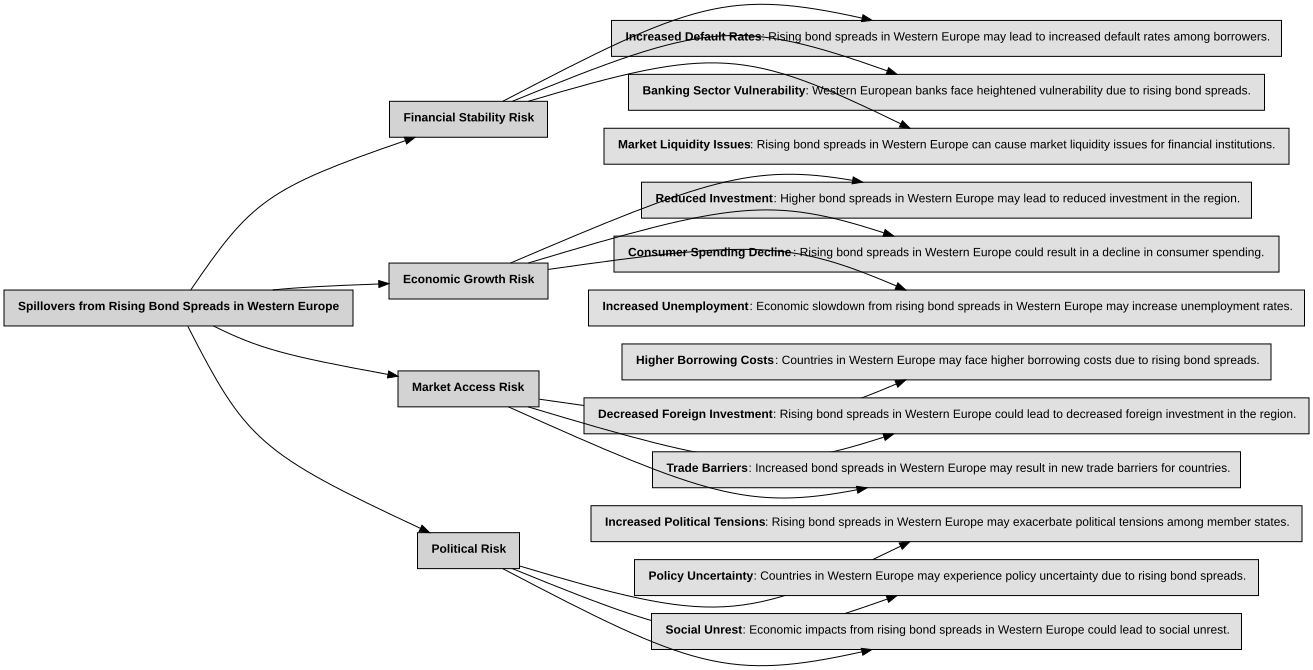

In [11]:
theme_tree = generate_risk_tree(
    main_theme=main_theme,
    analyst_focus=analyst_focus,
    system_prompt=get_entity_risk_prompt(main_theme, analyst_focus),
)

theme_tree.visualize()

The taxonomy tree includes descriptive sentences that explicitly connect each sub-theme back to the main theme, ensuring all search results remain contextually relevant to our central trend.

In [12]:
node_summaries = list(theme_tree.get_terminal_label_summaries().values())
labels = list(theme_tree.get_terminal_label_summaries().keys())

In [13]:
node_summaries

['Rising bond spreads in Western Europe may lead to increased default rates among borrowers.',
 'Western European banks face heightened vulnerability due to rising bond spreads.',
 'Rising bond spreads in Western Europe can cause market liquidity issues for financial institutions.',
 'Higher bond spreads in Western Europe may lead to reduced investment in the region.',
 'Rising bond spreads in Western Europe could result in a decline in consumer spending.',
 'Economic slowdown from rising bond spreads in Western Europe may increase unemployment rates.',
 'Countries in Western Europe may face higher borrowing costs due to rising bond spreads.',
 'Rising bond spreads in Western Europe could lead to decreased foreign investment in the region.',
 'Increased bond spreads in Western Europe may result in new trade barriers for countries.',
 'Rising bond spreads in Western Europe may exacerbate political tensions among member states.',
 'Countries in Western Europe may experience policy uncert

## Retrieve Content using Bigdata’s Search Capabilities

With the theme taxonomy and screening parameters, you can leverage the
Bigdata API to run a search on news or company transcripts. We need to define 3
more parameters for searching:

-  **Frequency** (``freq``): The frequency of the date ranges to search over.
   Supported values:

   -  `Y`: Yearly intervals.
   -  `M`: Monthly intervals.
   -  `W`: Weekly intervals.
   -  `D`: Daily intervals. Defaults to `3M`.

-  **Document Limit** (``document_limit``): The maximum number of documents to
   return per query to Bigdata API.
-  **Batch Size** (``batch_size``): The number of entities to include in a
   single batched query.

In [ ]:
freq = "M"
document_limit = 20
batch_size = 10

Retrieve news content related to Western European countries in relation to bond spreads and sovereign debt risks.


In [15]:
df_sentences_countries = search_by_entities(entities=entities_countries,
    sentences=node_summaries,
    start_date=start_date,
    end_date=end_date,
    scope=document_type,
    control_entities=control_entities,
    sources=None,
    fiscal_year=None,
    freq=freq,
    document_limit=document_limit,
    batch_size=batch_size
)
df_sentences_countries = df_sentences_countries.rename(columns={"sentiment": "bigdata_sentiment"})

Running 48 searches (12 queries over 4 date ranges)
Example query:
And(Similarity('Higher bond spreads in Western Europe may lead to reduced investment in the region.'), Or(Entity('E96159'), Place(id='C3FAF4', name='France', volume=None, description='The French Republic is a country located in Western Europe.', entity_type='PLCE', place_type='Country', country='France', region=None), Place(id='847BDC', name='Italy', volume=None, description='The Italian Republic is a country located in southern Europe.', entity_type='PLCE', place_type='Country', country='Italy', region=None), Place(id='986F1A', name='Spain', volume=None, description='The Kingdom of Spain is a country located in southwestern Europe on the Iberian Peninsula.', entity_type='PLCE', place_type='Country', country='Spain', region=None), Place(id='A20475', name='The Netherlands', volume=None, description='The Kingdom of the Netherlands is a country located in Northwestern Europe.', entity_type='PLCE', place_type='Country', cou

Processing news results...: 100%|██████████| 960/960 [00:00<00:00, 7884.20it/s]


Augment the search by retrieving news content mentioning institutional entities related to Western European countries.


In [16]:
df_sentences_banks = search_by_entities(entities=entities_banks,
    sentences=node_summaries,
    start_date=start_date,
    end_date=end_date,
    scope=document_type,
    control_entities=control_entities,
    sources=None,
    fiscal_year=None,
    freq=freq,
    document_limit=document_limit,
    batch_size=batch_size
)
df_sentences_banks = df_sentences_banks.rename(columns={"sentiment": "bigdata_sentiment"})


Running 48 searches (12 queries over 4 date ranges)
Example query:
And(Similarity('Higher bond spreads in Western Europe may lead to reduced investment in the region.'), Or(Entity('0425F5'), Organization(id='1184C3', name='Bank of France', volume=None, description='Bank of France, headquartered in Paris, is the central bank of France. It was founded on January 18, 1800.', entity_type='ORGA', organization_type='Central Bank', country='France'), Organization(id='270709', name='Central Bank of Italy', volume=None, description='The Bank of Italy, is the central bank of Italy and part of the European System of Central Banks. The bank was founded in 1893.', entity_type='ORGA', organization_type='Central Bank', country='Italy'), Organization(id='8FD0DB', name='Central Bank of Spain', volume=None, description='The Bank of Spain is the central bank of Spain. It was established in Madrid in 1782.', entity_type='ORGA', organization_type='Central Bank', country='Spain'), Organization(id='5EDABE', 

Processing news results...: 100%|██████████| 950/950 [00:00<00:00, 21355.93it/s]


Map institutional entities back to their respective countries and combine with country-level results to create a unified dataset for analysis.


In [ ]:
df_sentences_banks_mapped = df_sentences_banks.copy()
reverse_dict = {v: k for k, v in dict_country_bank.items()}
df_sentences_banks_mapped["entity_name"] = df_sentences_banks_mapped["entity_name"].map(reverse_dict)

df_combined = pd.concat([df_sentences_banks_mapped, df_sentences_countries], ignore_index=True)
df_combined = df_combined.drop_duplicates(subset=["entity_name", "sentence_id"], keep="first")

## Label the Results

Use an LLM to analyze each text chunk and determine its relevance to the sub-themes. Any chunks which aren't explicitly linked to our main theme will be filtered out.

In [19]:
labeler = RiskLabeler(llm_model=llm_model, label_prompt=get_risk_entity_labeler_prompt(main_theme, labels).strip())
df, df_labels = label_search_results(
            df_sentences = df_combined,
            terminal_labels = labels,
            risk_tree = theme_tree,
            labeler = labeler,
            additional_prompt_fields = ['headline'],
            main_theme = main_theme)



Querying OpenAI...:   0%|          | 0/1527 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 1527/1527 [01:11<00:00, 21.28it/s]


Retain only results with negative sentiment to focus on risk-related narratives and adverse developments in the bond spread and sovereign debt landscape.



In [ ]:
df_labels = df_labels.loc[df_labels.Sentiment.eq('negative')].copy()

## Assess Thematic Exposure Across Your Entities

The function `get_scored_df` will calculate the composite
thematic score, summing up the scores across the sub-themes for each
entity (`df_entity`).

In [21]:
df_entity = pd.DataFrame()

df_entity = get_scored_df(
    df_labels, index_columns=["Entity", "Country"], pivot_column="Sub-Scenario"
)

### Create Daily Sentiment Indicators
Generates a complete daily time grid for all entities and calculates rolling sentiment indicators (30/90 days), news volumes, and normalized metrics for temporal analysis.


In [22]:
daily_sentiment = create_full_grid_indicators(df_labels, start_date, end_date)

### Identify Peak Coverage and Sentiment Windows
Identifies time windows of maximum media coverage and most negative sentiment for each country, useful for analyzing critical risk moments.


In [23]:
peak_coverage_windows, peak_coverage_data = get_narrative_windows(daily_sentiment, df_labels, sentiment_col="Sent_Rolling_30Days", min_max='min', lookback_days=30)

### Generate AI-Powered Narrative Summaries

Uses an LLM to synthesize the main narratives in peak windows, providing a qualitative summary of the risks that emerged for each country during the most critical moments.


In [24]:
summarizer = SummaryGenerator()
entity_narratives = summarize_narratives(df_labels, entities_countries, summarizer, peak_coverage_windows)

Processing entity: Austria
  Processing window type: volume with 3 records
  Processing window type: sentiment with 0 records
Completed processing for entity: Austria

Processing entity: Belgium
  Processing window type: volume with 4 records
  Processing window type: sentiment with 2 records
Completed processing for entity: Belgium

Processing entity: France
  Processing window type: volume with 52 records
  Processing window type: sentiment with 129 records
Completed processing for entity: France

Processing entity: Germany
  Processing window type: volume with 30 records
  Processing window type: sentiment with 43 records
Completed processing for entity: Germany

Processing entity: Greece
  Processing window type: volume with 13 records
  Processing window type: sentiment with 13 records
Completed processing for entity: Greece

Processing entity: Ireland
  Processing window type: volume with 1 records
  Processing window type: sentiment with 4 records
Completed processing for entity

Ranks countries based on the most negative sentiment values recorded, identifying which nations show the highest level of concern for bond spread risks and sovereign debt pressures.



In [25]:
ranked_countries = pd.DataFrame.from_dict(peak_coverage_data, orient='index').sort_values(by='sentiment_value', ascending=True)
ranked_countries

,volume_index,volume_value,sentiment_index,sentiment_value
France,2025-08-26,13.0,2025-09-23,-10.361542
Germany,2025-09-30,10.0,2025-09-15,-8.756806
Italy,2025-09-30,9.0,2025-10-02,-5.412611
Greece,2025-10-03,3.0,2025-10-03,-4.260000
Spain,2025-10-03,4.0,2025-09-16,-2.415000
Portugal,2025-08-26,3.0,2025-09-08,-2.123333
The Netherlands,2025-09-01,2.0,2025-09-24,-1.440000
Belgium,2025-08-27,2.0,2025-08-26,-1.260000
Ireland,2025-08-03,1.0,2025-09-01,-1.040000
Austria,2025-08-27,2.0,2025-07-01,0.000000


## Visualizations

Generates interactive dashboards for each country with sentiment time series charts, gauge indicators, and qualitative narratives at peak coverage or negativity moments.


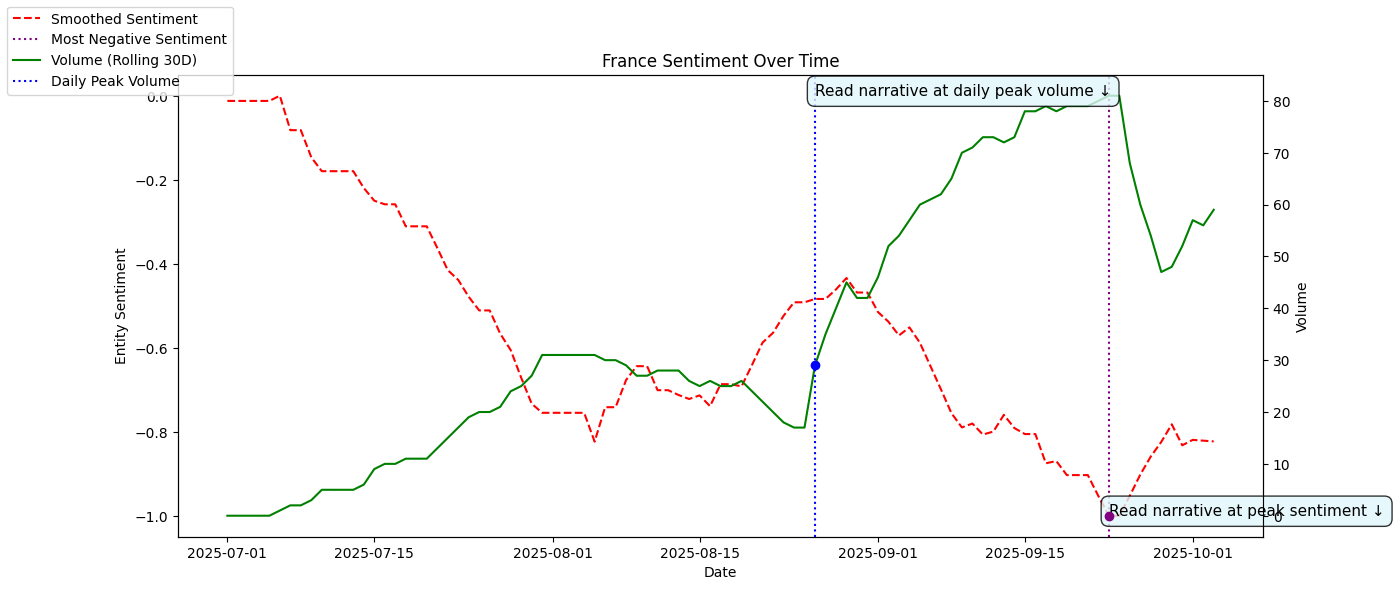

## Peak Volume Narrative

France is currently facing significant refinancing risk in real estate, exacerbated by a confluence of political instability, rising borrowing costs, and economic stagnation. Recent headlines highlight the European Central Bank's cautious stance amid global trade tensions, with ECB President Christine Lagarde warning of persistent downside risks, including the impact of U.S. tariffs on European economies. The introduction of a 15% tariff on European goods has led to skepticism about the EU's economic resilience, with French officials condemning the deal as detrimental to their economic power. As a result, France's 10-year bond yields have surged, now among the highest in the eurozone, reflecting investor concerns over the country's fiscal sustainability and political turmoil. The yield spread between French and German bonds has widened significantly, indicating a loss of confidence in France's ability to manage its substantial public debt, which is projected to reach 118% of GDP by 2026. This situation is compounded by a sluggish domestic economy, where high household savings rates and declining consumption have stifled growth. The potential collapse of the current government adds further uncertainty, with analysts warning that failure to implement necessary fiscal reforms could lead to a credit rating downgrade and increased borrowing costs. Consequently, the real estate sector, heavily reliant on stable financing conditions, faces heightened risks as market access becomes more challenging and investor sentiment deteriorates. The convergence of France's borrowing costs with those of historically riskier economies like Italy underscores a critical shift in market perception, raising alarms about the sustainability of France's economic trajectory amidst a backdrop of political and fiscal instability.

## Most Negative Sentiment Narrative

France is currently facing significant refinancing risk in real estate and broader financial markets, as highlighted by a series of alarming news reports from August and September 2025. The political crisis surrounding Prime Minister François Bayrou's government has led to soaring bond yields, with French 10-year bond rates climbing above those of traditionally riskier nations like Italy and Greece, reflecting a loss of investor confidence in France's fiscal sustainability. The yield spread between French and German bonds has widened to levels not seen since the eurozone debt crisis, indicating that investors are demanding higher compensation for holding French debt due to fears of increased default rates and market liquidity issues. The government's struggle to implement necessary austerity measures amidst political instability has exacerbated these concerns, with analysts warning that failure to address the ballooning national debt—projected to reach 130% of GDP—could lead to a credit rating downgrade and potential intervention from the International Monetary Fund. The situation is further complicated by rising borrowing costs, which are expected to hinder economic growth and increase the financial strain on both public and private sectors, particularly impacting the banking sector that is heavily exposed to government bonds. As France navigates this precarious landscape, the outlook remains grim, with the potential for a deeper crisis if political deadlock continues and fiscal reforms are not enacted swiftly.

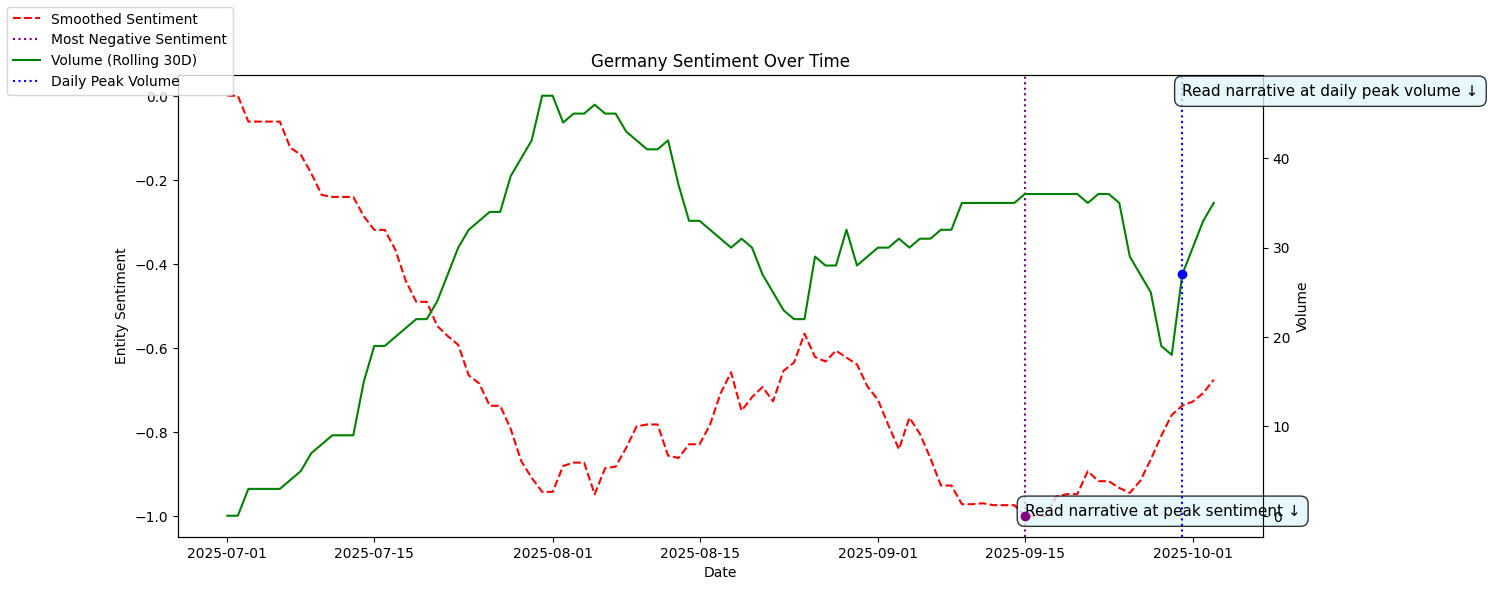

## Peak Volume Narrative

Germany is currently facing significant refinancing risk in its real estate and broader financial markets, as highlighted by a series of concerning developments in September 2025. The yield on Germany's 30-year bonds has surged to 3.40%, the highest in over a decade, amid a broader selloff in European bond markets driven by rising public debt and political instability, particularly in France. This situation is exacerbated by the European Central Bank's (ECB) reluctance to intervene decisively, as indicated by analysts who suggest that current market conditions do not warrant a response from the ECB. The rising borrowing costs are not only a reflection of Germany's own fiscal challenges but also of contagion effects from neighboring countries, where yields have reached alarming levels, raising fears of a potential eurozone debt crisis. The economic backdrop is further complicated by Germany's own deteriorating economic indicators, including a rise in unemployment to 6.3% and a decline in retail sales, which signal a weakening domestic economy. As Germany prepares to issue new government bonds to finance its spending, the market's appetite for these bonds is likely to be tempered by concerns over fiscal sustainability and the potential for increased default rates. The combination of high borrowing costs, economic stagnation, and external pressures from geopolitical uncertainties creates a precarious environment for Germany, necessitating strategic measures to stabilize its financial landscape and restore investor confidence.

## Most Negative Sentiment Narrative

Germany is currently facing significant refinancing risks in real estate and broader economic challenges, as highlighted by a series of concerning news reports from August and September 2025. The Bundesbank's refurbishment project has encountered substantial cost overruns, coinciding with a period of massive losses attributed to prolonged zero interest rates and extensive bond purchases by the European Central Bank (ECB), raising alarms about financial stability. Concurrently, the German government is grappling with rising borrowing costs, with 30-year yields surpassing 3% for the first time since 2011, driven by plans to increase infrastructure and defense spending. This shift towards higher debt levels has sparked fears of a "new era of fiscal dominance," potentially leading to increased exposure to interest rate fluctuations. The economic landscape is further complicated by a rising unemployment rate, which has now exceeded 3 million for the first time in a decade, reflecting structural changes in the labor market and a sluggish recovery from recession. As consumer confidence wanes, the outlook for economic growth remains bleak, with GDP contracting by 0.3% in the second quarter. The combination of these factors—escalating borrowing costs, rising unemployment, and a fragile economic recovery—signals a precarious situation for Germany, which may struggle to maintain its historical reputation for fiscal prudence and economic stability. Investors are advised to closely monitor these developments, as the potential for increased default rates and market liquidity issues looms large, particularly in light of the ongoing political instability in neighboring France, which could further exacerbate Germany's economic challenges.

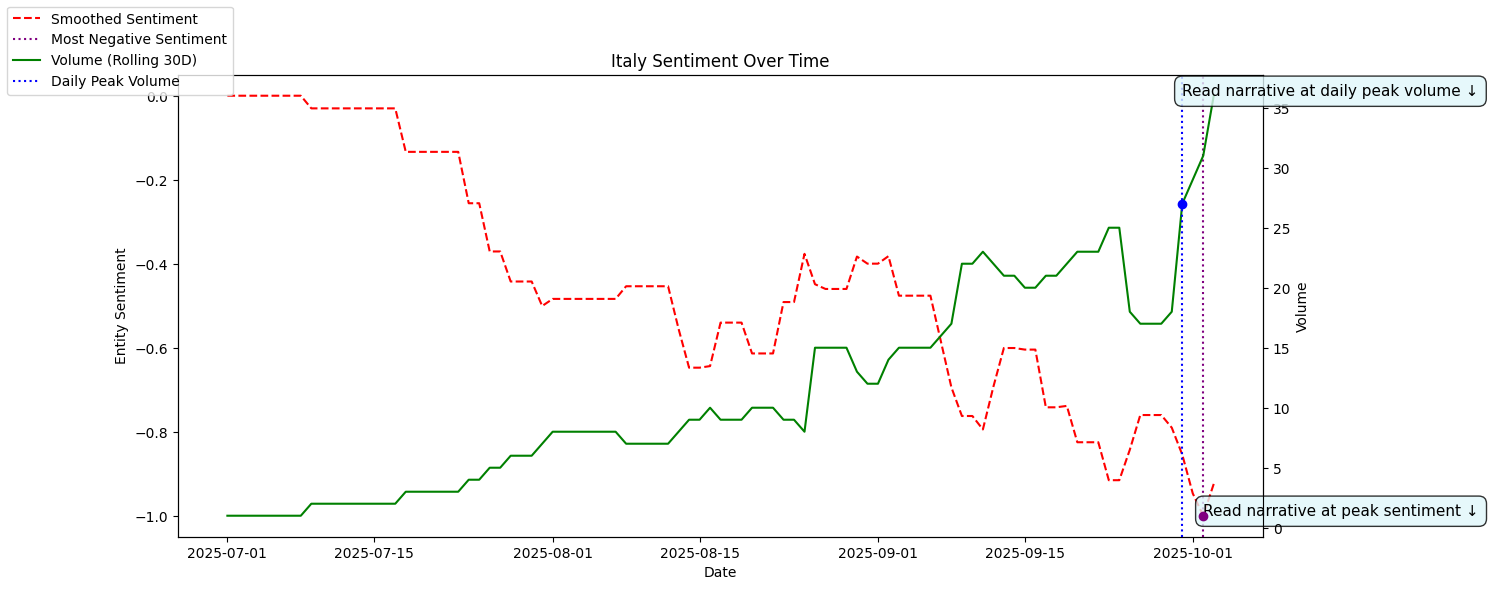

## Peak Volume Narrative

Italy is currently facing significant refinancing risk in the real estate sector, exacerbated by rising bond yields and increasing borrowing costs across Europe. Recent news highlights that Italy's 10-year bond yield has climbed to 3.68%, reflecting broader market pressures as yields in France and Germany also surge, with France's 30-year bonds reaching a 14-year high of over 4.5%. This environment of escalating yields is particularly concerning as it signals a tightening of market access for borrowers, which could lead to higher costs for refinancing existing debts. The situation is compounded by Italy's historical reputation as a fiscal laggard within the Eurozone, a perception that has been challenged recently due to political stability under Prime Minister Giorgia Meloni. However, the ongoing economic strain, including a projected budget deficit and rising debt-to-GDP ratio, raises alarms about Italy's financial health. Investors are increasingly wary, as evidenced by comparisons of Italy's borrowing costs with those of traditionally riskier nations like Greece, indicating a shift in market sentiment. The potential consequences of these dynamics include reduced investment in the real estate sector, increased default rates, and a broader economic slowdown, as higher borrowing costs could stifle growth and consumer spending. As Italy navigates these challenges, stakeholders must closely monitor bond market trends and consider strategic measures to mitigate refinancing risks, particularly in light of the evolving economic landscape in Europe.

## Most Negative Sentiment Narrative

Italy is currently facing significant refinancing risk in the context of rising borrowing costs and market access challenges, as highlighted by recent news coverage. On September 3, 2025, Italy's 30-year BTP yields surged to 4.68%, reflecting broader market pressures as U.S. Treasury yields reached a decade-high, driven by concerns over debt growth and inflation. This trend is compounded by the political and economic instability in neighboring France, where borrowing costs have escalated, edging closer to Italy's yields, which were historically viewed as a marker of fiscal irresponsibility. The situation is exacerbated by Italy's own high debt-to-GDP ratio, which, while not the highest in the EU, places it in a precarious position as investor confidence wavers. The potential for a bond crisis looms, with analysts suggesting that Italy could be among the countries most at risk if market conditions deteriorate further. The consequences of these developments could lead to increased costs of borrowing for the Italian government and businesses, reduced foreign investment, and a potential slowdown in economic growth, as indicated by the OECD's forecasts. As Italy navigates these challenges, it is crucial for policymakers to implement measures that enhance fiscal stability and restore investor confidence to mitigate the risks associated with refinancing in the current volatile market environment.

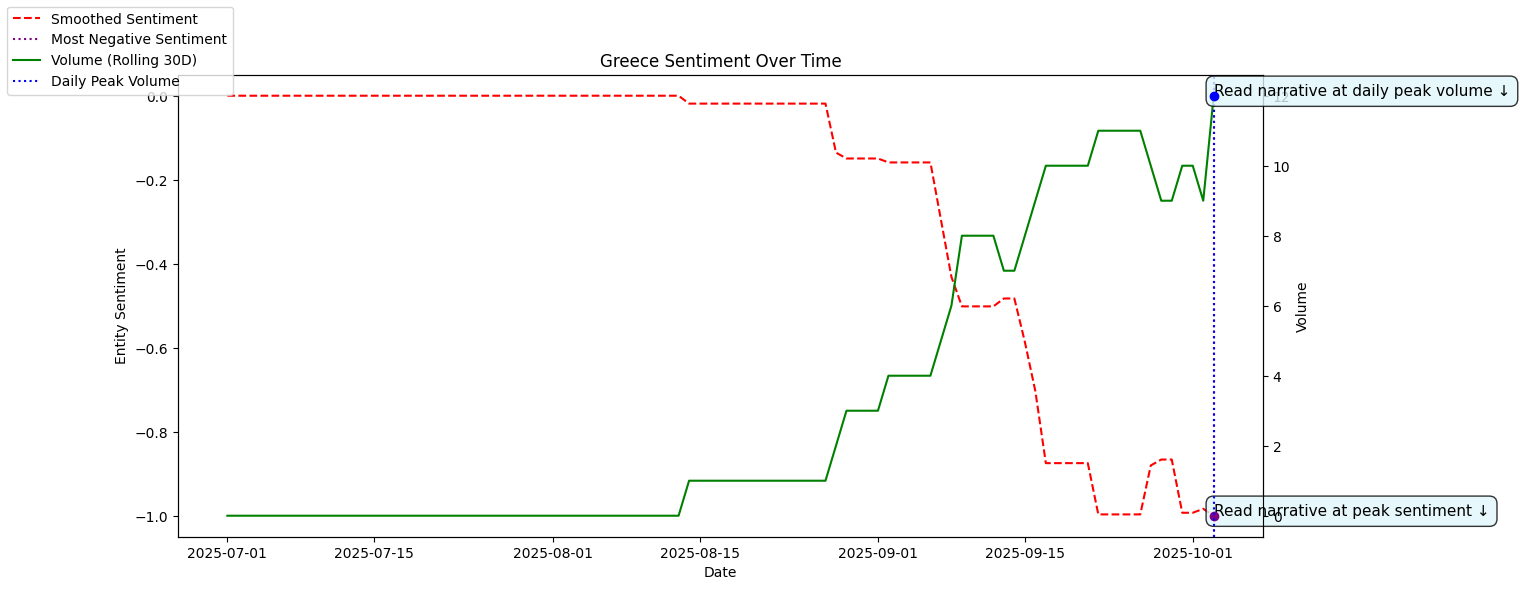

## Peak Volume Narrative

Greece is currently facing heightened refinancing risk as it finds itself in a precarious position amidst the evolving dynamics of the Eurozone debt landscape, particularly in light of France's recent economic turmoil. As reported on September 9, 2025, France's ten-year bond yields have surpassed those of Greece, indicating a shift in market perceptions where Greece, once a focal point of Eurozone instability, is now viewed as a relatively safer investment compared to its historically more stable counterpart. This shift is underscored by France's soaring debt-to-GDP ratio, projected to reach 125% by 2030, and a budget deficit that remains the largest in the EU, which has led to increased borrowing costs and investor anxiety. The implications for Greece are significant; while it has regained investment-grade status, the rising yields in France and the potential for a broader Eurozone crisis could lead to increased volatility in Greek bonds as investors reassess risk across the region. The current environment suggests that Greece must remain vigilant, as any resurgence of instability in France or other Eurozone nations could trigger a reevaluation of its own financial standing, potentially leading to higher borrowing costs and constrained market access.

## Most Negative Sentiment Narrative

Greece is currently facing heightened refinancing risk as it finds itself in a precarious position amidst the evolving dynamics of the Eurozone debt landscape, particularly in light of France's recent economic turmoil. As reported on September 9, 2025, France's ten-year bond yields have surpassed those of Greece, indicating a shift in market perceptions where Greece, once a focal point of Eurozone instability, is now viewed as a relatively safer investment compared to its historically more stable counterpart. This shift is underscored by France's soaring debt-to-GDP ratio, projected to reach 125% by 2030, and a budget deficit that remains the largest in the EU, which has led to increased borrowing costs and investor anxiety. The implications for Greece are significant; while it has regained investment-grade status, the rising yields in France and the potential for a broader Eurozone crisis could trigger a reevaluation of Greece's own fiscal health and market access. The interconnectedness of these economies means that any deterioration in France's financial stability could reverberate through the Eurozone, potentially impacting Greece's borrowing costs and economic recovery trajectory. As such, stakeholders should closely monitor developments in France and the broader Eurozone, as shifts in market sentiment could lead to increased volatility and refinancing challenges for Greece in the near future.

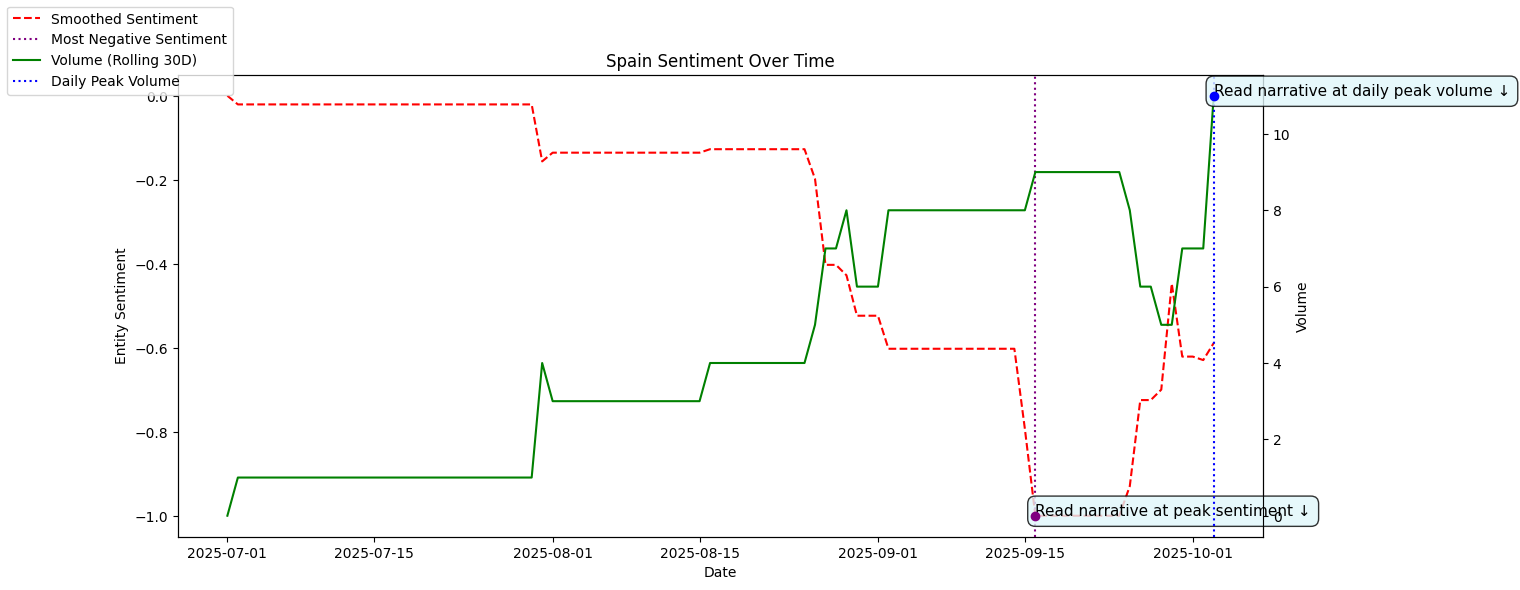

## Peak Volume Narrative

Spain is currently facing significant refinancing risks in its real estate sector, exacerbated by broader financial stability concerns across Europe. Recent news highlights that Spain's bond yields are rising, with the country now facing higher borrowing costs compared to its peers, such as France, which has seen a downgrade in its credit rating leading to increased investor anxiety. The European Central Bank's (ECB) policies, including negative interest rates, have created a precarious environment, contributing to a 20% increase in default risk over the past year, as indicated by rising credit default swap prices. This situation is compounded by the historical context of Spain's vulnerability during the eurozone banking crisis, where sudden capital flow stops left the country exposed. Furthermore, the reliance on small and medium-sized enterprises (SMEs) in Spain, which struggle to access market-based credit due to high costs associated with bond issuance, adds another layer of risk. As the economic landscape shows signs of subdued momentum, with GDP growth stepping down, the potential for increased defaults looms large, threatening not only the real estate market but also the broader financial stability of the region. The interplay of these factors suggests that stakeholders should closely monitor refinancing conditions and consider strategic adjustments to mitigate risks associated with rising borrowing costs and market access challenges.

## Most Negative Sentiment Narrative

Spain is currently facing heightened refinancing risk in real estate, exacerbated by broader financial instability in Europe, particularly stemming from political turmoil in France. Recent news highlights that Spain's bond yields, while currently lower than those of France, are under pressure as the yield on French 10-year government bonds has surpassed Spain's, indicating a shift in market sentiment and access risk. Analysts warn that the potential for a financial crisis in Europe could originate from vulnerabilities within banks in Spain, France, and Italy, despite their strong capital ratios. The ongoing political instability in France, marked by a looming debt crisis and potential government collapse, has led to increased market volatility, impacting Spain's financial landscape as well. The spread between German and French bonds has widened, suggesting that Spain's market access could be affected if investor confidence continues to wane. Furthermore, rising bond yields across Europe, driven by fiscal and political uncertainties, could lead to higher borrowing costs for Spain, complicating refinancing efforts in the real estate sector. As Spain navigates these challenges, stakeholders must remain vigilant to the evolving risks and consider proactive measures to mitigate potential impacts on market access and financial stability.

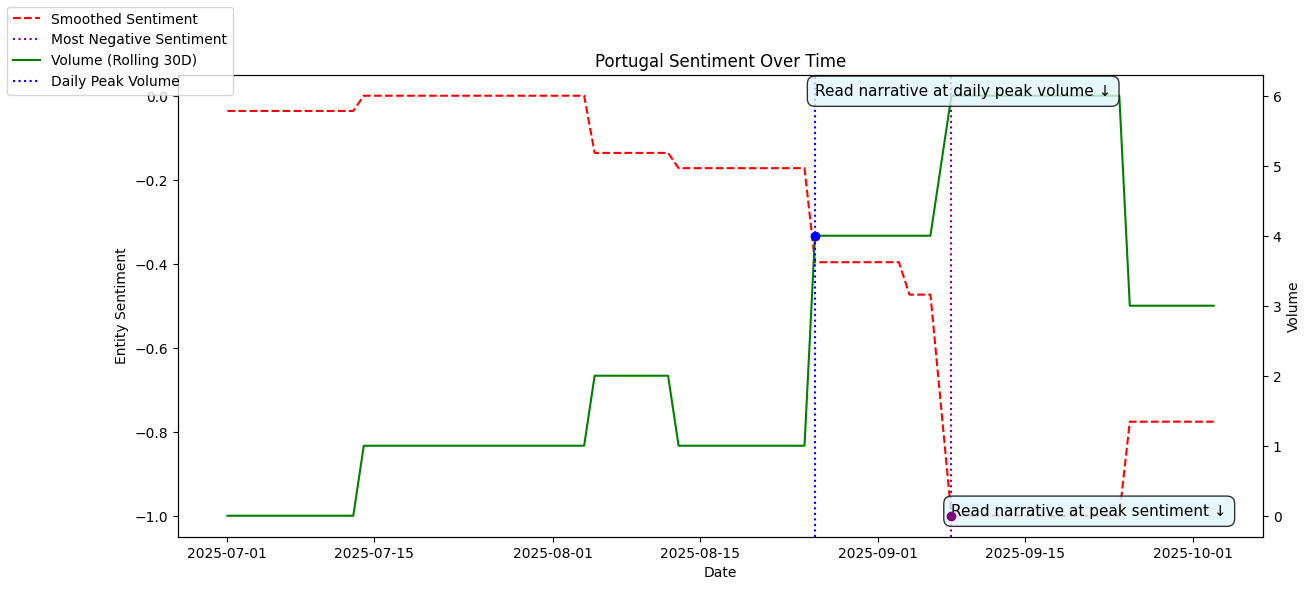

## Peak Volume Narrative

Portugal is currently facing significant refinancing risk in real estate, exacerbated by broader economic challenges highlighted in recent news. The OECD has warned that weak business investment, driven by "pervasive" policy uncertainty and external shocks, is threatening global growth, with Portugal being particularly vulnerable as it grapples with rising borrowing costs. As France's 10-year yields have surged to levels surpassing those of Portugal, the country is experiencing increased market access risk, which could lead to higher costs for refinancing existing debt. This situation is compounded by fears of financial instability, as elevated yields raise concerns about default rates, reminiscent of past crises in the Eurozone. The interconnectedness of these risks suggests that Portugal's economic outlook is precarious, with potential consequences for both public and private sector stakeholders, as they may face tighter financial conditions and reduced investment capacity. The current climate calls for close monitoring of market trends and proactive measures to mitigate refinancing risks, particularly as sentiment shifts in response to ongoing economic developments.

## Most Negative Sentiment Narrative

Portugal is facing heightened refinancing risk as it grapples with rising borrowing costs and market access challenges, exacerbated by the political and economic instability in France. Recent reports indicate that France's 10-year bond yields have surged to levels surpassing those of Portugal and Greece, signaling a potential return to the financial strains reminiscent of the Eurozone debt crisis. This situation is compounded by the European Central Bank's concerns over market liquidity and the vulnerabilities of payment infrastructures, particularly highlighted by incidents affecting Portugal. As borrowing costs rise, Portugal's financial stability could be jeopardized, leading to increased default rates and a tightening of market access. The interconnectedness of European economies means that Portugal's risk profile is closely tied to developments in France, with potential spillover effects that could hinder economic recovery and investor confidence. The current environment necessitates vigilant monitoring of market trends and proactive measures to mitigate refinancing risks, as the outlook remains uncertain amid broader regional instability.

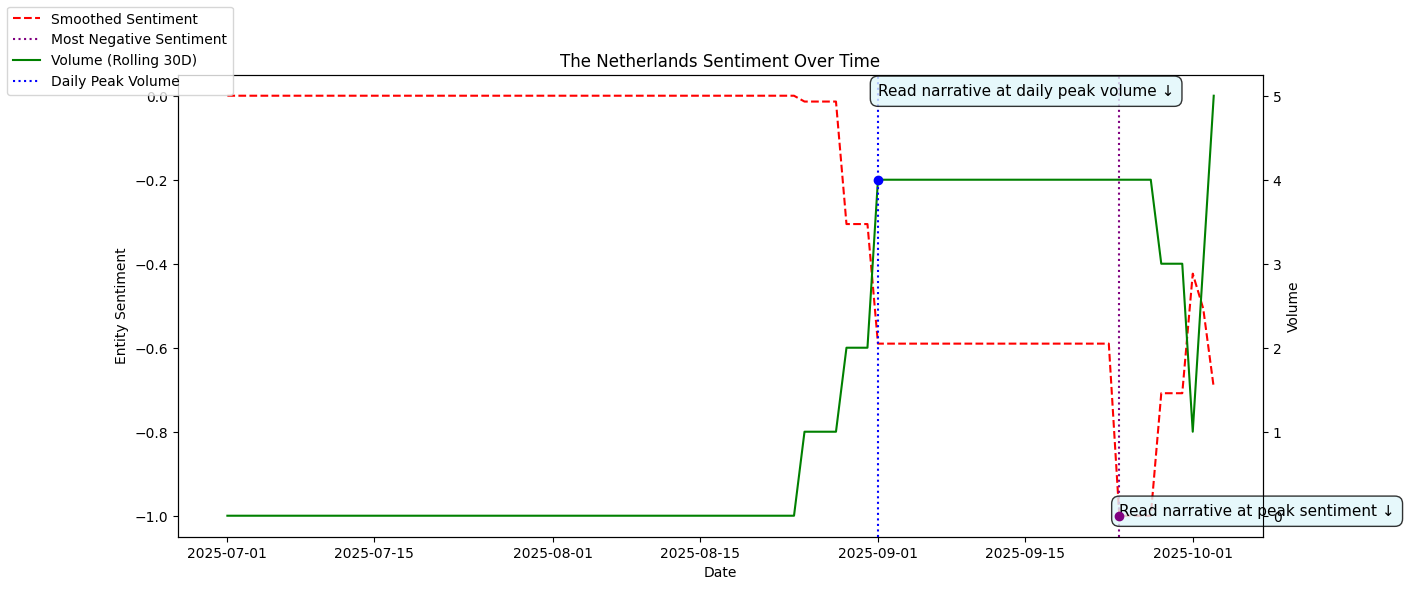

## Peak Volume Narrative

The Netherlands is currently facing significant refinancing risks in its real estate sector, exacerbated by a combination of political and financial stability challenges. Recent news highlights a EUR2.6 million fine imposed on the neobank Bunq for anti-money laundering (AML) lapses, reflecting ongoing tensions with the Dutch central bank (DNB) over regulatory compliance, which could impact investor confidence in the financial sector. Additionally, the impending transition to a full defined contribution pension system by 2028 raises concerns about market access and borrowing costs, as citizens shift from public to private pension plans amidst rising financial pressures. This shift is compounded by a broader European context where bond yields, including those in the Netherlands, have surged to 14-year highs, indicating heightened volatility and liquidity issues in the bond markets. The DNB has warned of potential risks to financial stability, suggesting that the complexities of these reforms could lead to significant disruptions. As the Netherlands navigates these intertwined risks, the outlook for real estate refinancing remains precarious, with stakeholders facing increased uncertainty and potential cost escalations.

## Most Negative Sentiment Narrative

The Netherlands is currently facing significant refinancing risk in its real estate sector, exacerbated by a broader financial stability crisis linked to its pension fund reforms and rising bond yields. As highlighted in recent news, the transition to a defined contribution pension system, set to be fully implemented by 2028, has led to increased market access risks and higher borrowing costs for both individuals and institutions. The surge in long-dated bond yields, which reached 14-year highs in August 2025, has compounded these challenges, with Dutch bonds moving in tandem with rising yields across Europe, indicating a tightening financial environment. The Dutch central bank has warned of potential disruptions to financial stability, particularly as the market braces for a near EUR2 trillion upheaval due to pension fund adjustments. Furthermore, Dutch financial institutions reported substantial losses of EUR23 billion on foreign government bonds in the first half of 2025, driven by rising interest rates, which could further strain liquidity and increase default rates. This confluence of factors not only raises concerns about the sustainability of real estate financing but also signals a precarious outlook for the Dutch economy as it navigates these intertwined risks.

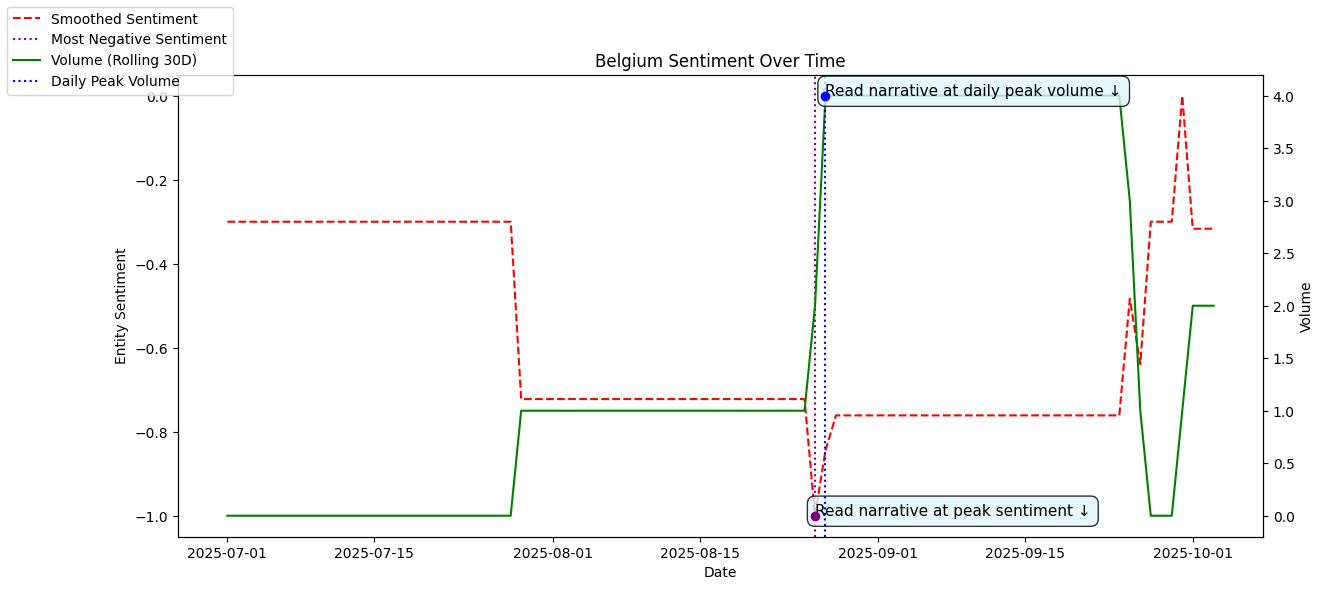

## Peak Volume Narrative

Belgium is currently facing significant refinancing risks in real estate, exacerbated by broader market access and financial stability concerns highlighted in recent news. The EU-US trade deal, reported on July 29, 2025, raises alarms about escalating trans-Atlantic trade tensions, which could disrupt the highly integrated global supply chains that Belgian exporters rely on, leading to increased costs and reduced competitiveness. This situation is compounded by the political instability in France, as noted on August 26, 2025, which has triggered a market correction and wider bond spreads, with Belgium's spread expected to reach 70 basis points by year-end. The ongoing scrutiny from rating agencies regarding Belgium's budgetary concerns, as mentioned on August 27, 2025, further heightens the risk of increased default rates, particularly as investor sentiment shifts towards more stable economies like Italy and Spain. The combination of these factors suggests a precarious outlook for Belgium's real estate market, where refinancing risks could lead to adverse consequences for consumers and small- to medium-sized enterprises, ultimately threatening economic stability in the region.

## Most Negative Sentiment Narrative

Belgium is currently facing significant refinancing risks in the real estate sector, exacerbated by broader market access challenges and rising borrowing costs. Recent news highlights concerns stemming from a potential EU-US trade deal that could escalate trans-Atlantic tensions, as noted on July 29, 2025, where experts warned that blanket tariffs would increase costs for European exporters, including those in Belgium, thereby reducing competitiveness and potentially leading to retaliatory measures. This situation is compounded by the political instability in France, which has triggered a market correction and wider spreads in eurozone bonds, as reported on August 26, 2025. The anticipated collapse of the French government has already led to a rise in the OAT-Bund spread, with Belgium's own spread expected to widen, reflecting increased borrowing costs and market volatility. The interconnectedness of Belgium's economy with France and the broader eurozone means that these developments could lead to heightened refinancing risks for Belgian real estate, impacting consumers and small to medium-sized enterprises. As such, stakeholders should closely monitor these evolving dynamics, as the potential for increased costs and reduced market access could have lasting implications for Belgium's economic stability and growth prospects.

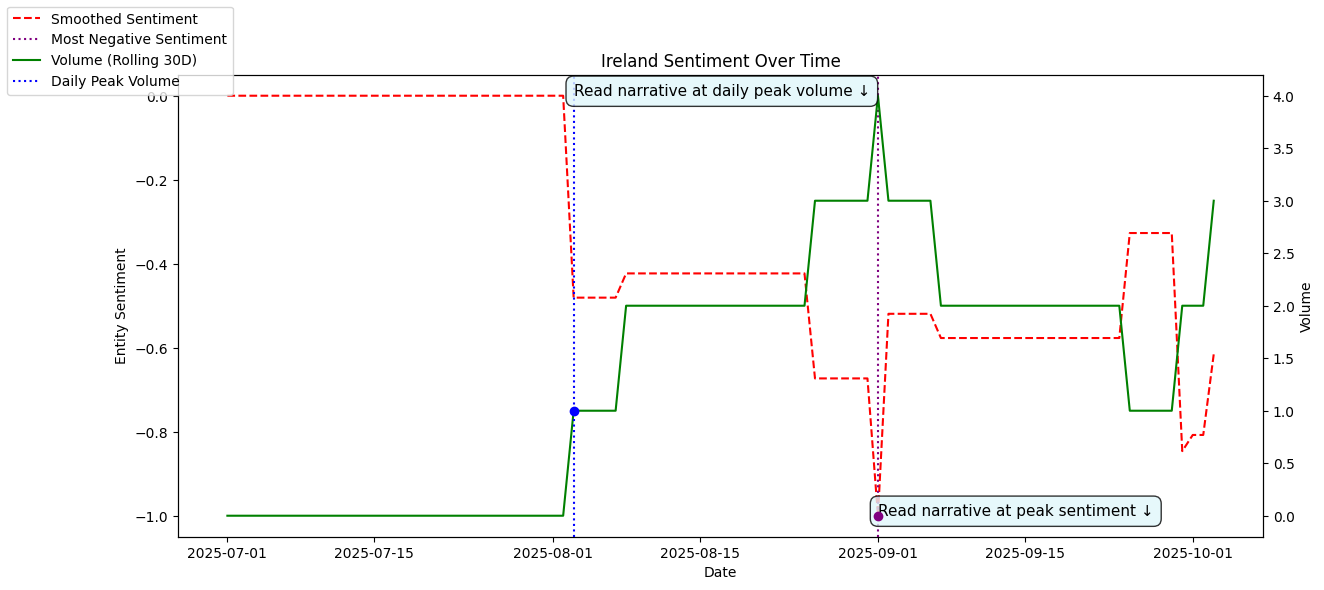

## Peak Volume Narrative

Ireland is facing significant refinancing risk in its real estate sector, as highlighted by the central bank's warnings regarding the potential negative impact of the upcoming October budget on the economy. The central bank governor has expressed concerns that the government's proposed tax cuts and increased spending could exacerbate the already precarious economic situation, which is characterized by sluggish growth and rising inflation. The uncertainty surrounding potential tariff increases by the U.S. further complicates the fiscal landscape, as these could lead to a reduction in the planned 9.4 billion euro tax cuts and higher expenditures in 2026. This environment of economic instability raises the stakes for real estate refinancing, as higher borrowing costs and reduced consumer confidence could lead to a decline in property values and increased default risks. Compared to other European nations, Ireland's situation appears particularly vulnerable, suggesting that stakeholders should closely monitor fiscal developments and prepare for potential market corrections.

## Most Negative Sentiment Narrative

Ireland is currently facing significant refinancing risk in its real estate sector, exacerbated by a combination of economic downturns and political uncertainties. The central bank's governor has warned that the upcoming October budget could further deteriorate the already fragile economic state, as indicated in the August 3rd report, which highlights a potential reduction in tax cuts and increased expenditure amidst fears of rising US tariffs. This economic backdrop is compounded by heightened policy uncertainty stemming from shifting US trade policies, which have created a volatile environment for Ireland's small, open economy, as noted in the August 8th coverage. While the unemployment rate remains low at 4.3%, the demand for residential rental accommodation is expected to stay strong due to a significant supply-demand imbalance. However, the political landscape is increasingly fraught, with protests against the Central Bank's involvement in Israeli bond sales, reflecting rising political tensions and public dissent, as reported on August 26th and September 1st. These developments not only threaten to destabilize investor confidence but also pose risks to the broader economic outlook, potentially leading to a slowdown in domestic economic activity and impacting the real estate market's resilience. The combination of these factors suggests that Ireland's real estate sector may face increased refinancing challenges, necessitating close monitoring of both economic indicators and political developments to navigate the evolving landscape effectively.

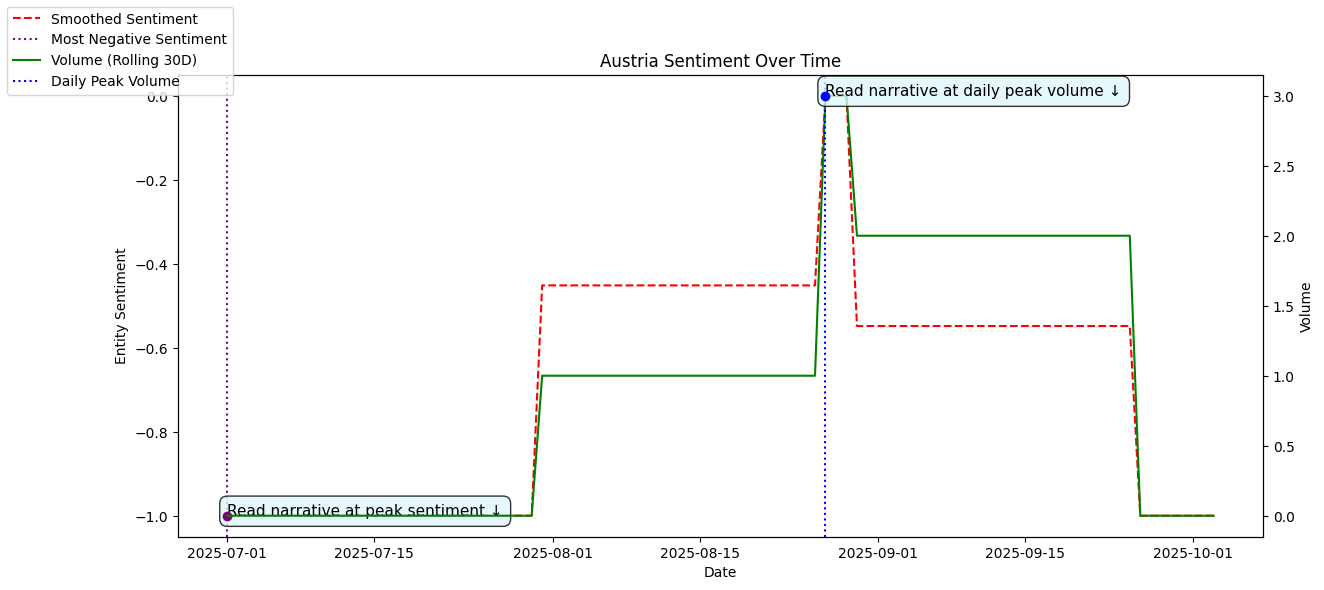

## Peak Volume Narrative

Austria is currently facing significant refinancing risk in the real estate sector, as highlighted by recent news coverage indicating rising scrutiny from rating agencies due to budgetary concerns. As of late July 2025, Austria, alongside other nations like Poland and Denmark, has seen an increase in unemployment, which could dampen consumer confidence and spending, further straining the real estate market. The economic backdrop is compounded by financial stability risks, with bond spreads widening amid political turmoil in France, which has led to increased scrutiny of Austria's fiscal health. This situation is exacerbated by contrasting trends in the Eurozone, where countries like Italy and Spain are experiencing positive sentiment and rating upgrades, leaving Austria at a disadvantage. The potential consequences of these risks include higher borrowing costs, reduced investment in real estate, and a possible slowdown in economic growth, which could lead to a more pronounced downturn in the property market. Stakeholders should closely monitor these developments, as the interplay of rising unemployment and financial scrutiny could signal a challenging environment for refinancing and overall economic stability in Austria.

## Most Negative Sentiment Narrative

Austria's real estate sector is currently facing significant refinancing risks, as highlighted by recent news coverage. The combination of rising interest rates and a tightening credit environment has led to increased concerns about the sustainability of property investments. Analysts warn that many property owners may struggle to refinance existing loans, particularly as the cost of borrowing escalates. This situation is exacerbated by a slowdown in economic growth and potential regulatory changes aimed at curbing speculative investments in real estate. The severity of these risks is underscored by comparisons to other European markets, where similar pressures are being felt, but Austria's reliance on domestic banks for financing could lead to a more pronounced impact. Stakeholders, including investors and homeowners, must remain vigilant as the potential for a market correction looms, driven by affordability challenges and a possible decline in property values.

In [30]:
gauge_value = "mean"                                    # Options: "min", "mean"
sentiment_col_to_use = 'Sent_Rolling_30Days_Normalized' # Options: 'Sent_Rolling_30Days' or 'Sent_Rolling_30Days_Normalized'

for entity in ranked_countries.index:

    display_dashboard(daily_sentiment, entity, 'Sent_Rolling_30Days_Normalized', narratives=entity_narratives , volume_type = "rolling",export_mode = True, gauge_value = gauge_value)


Creates comparative visualizations of risk scores across countries, showing aggregated exposure to different risk channels identified in the thematic analysis.


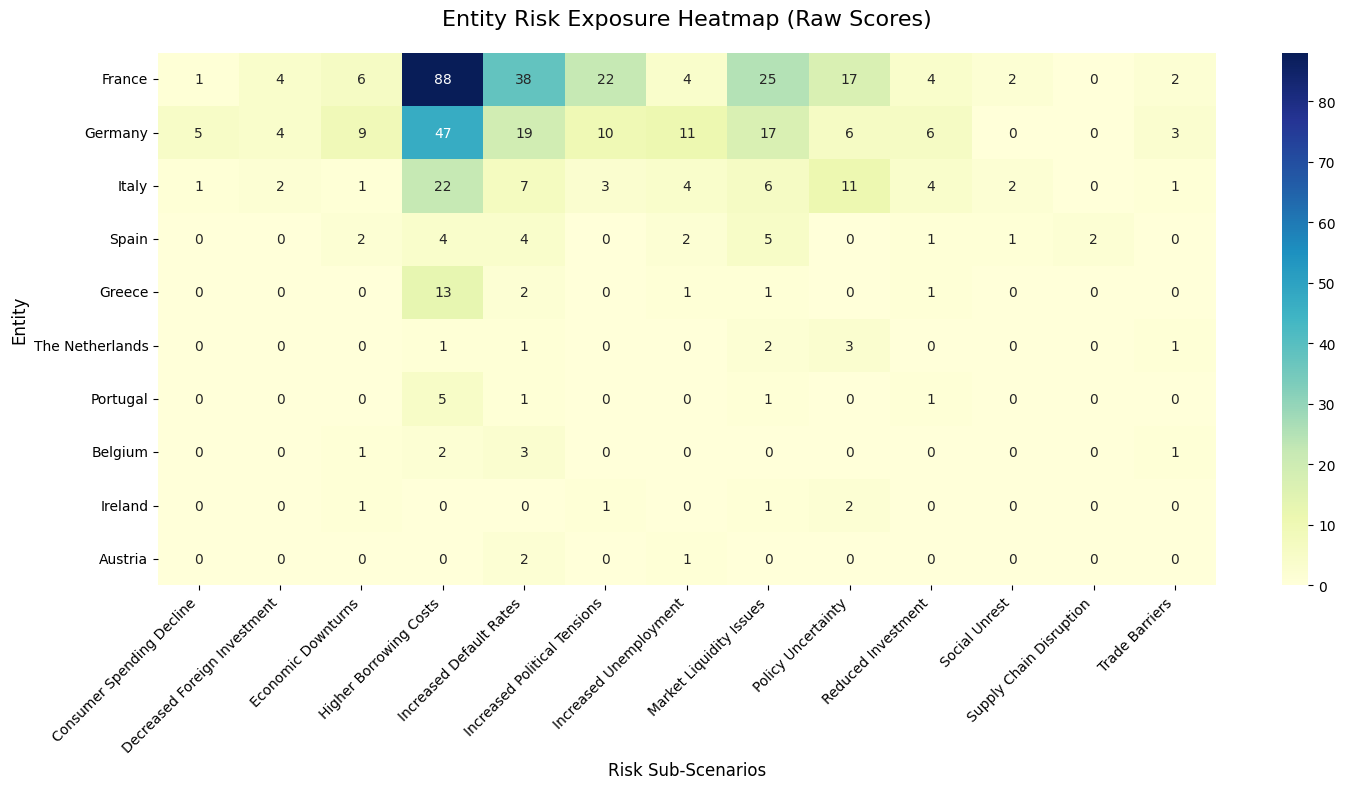

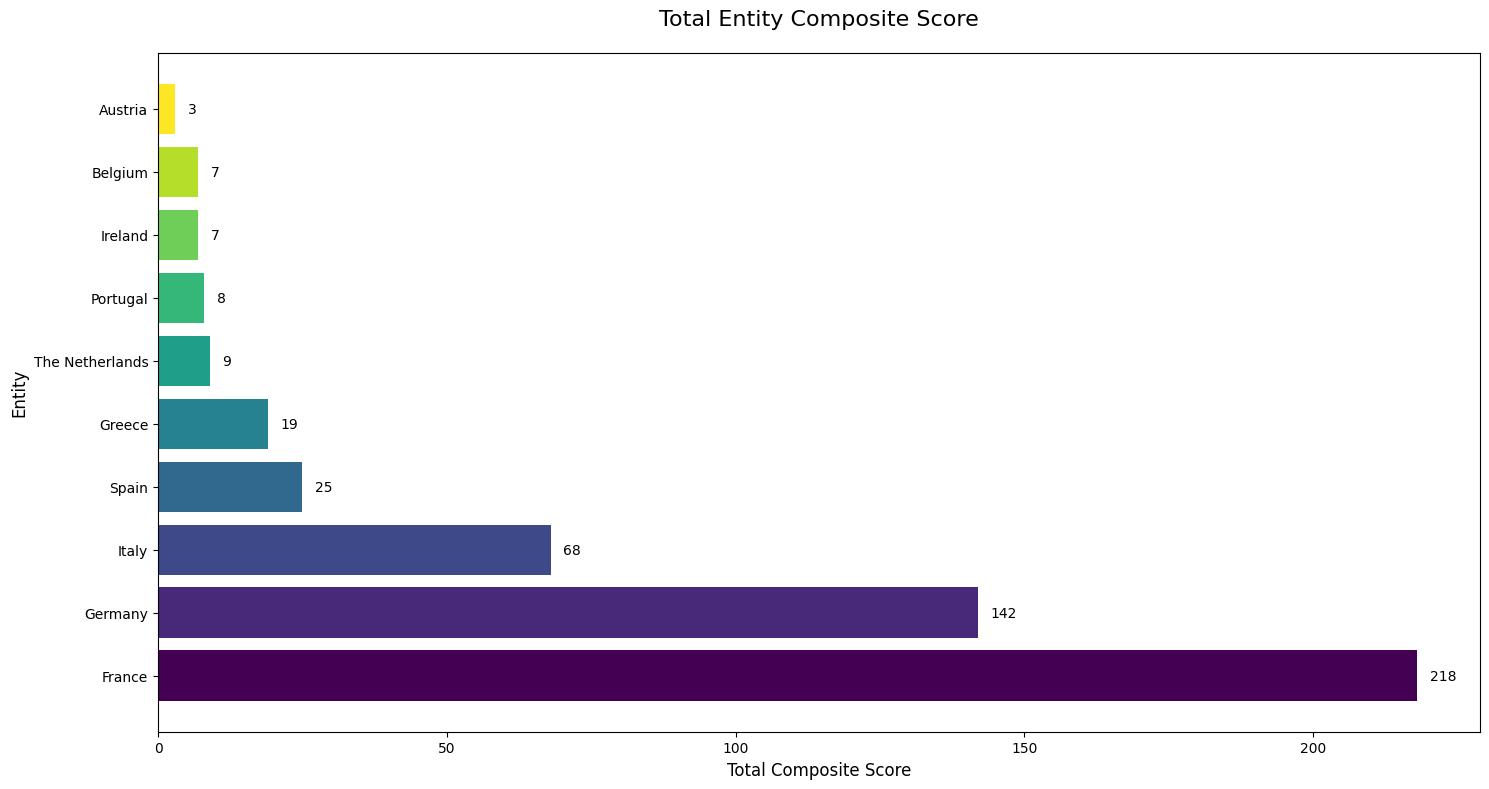

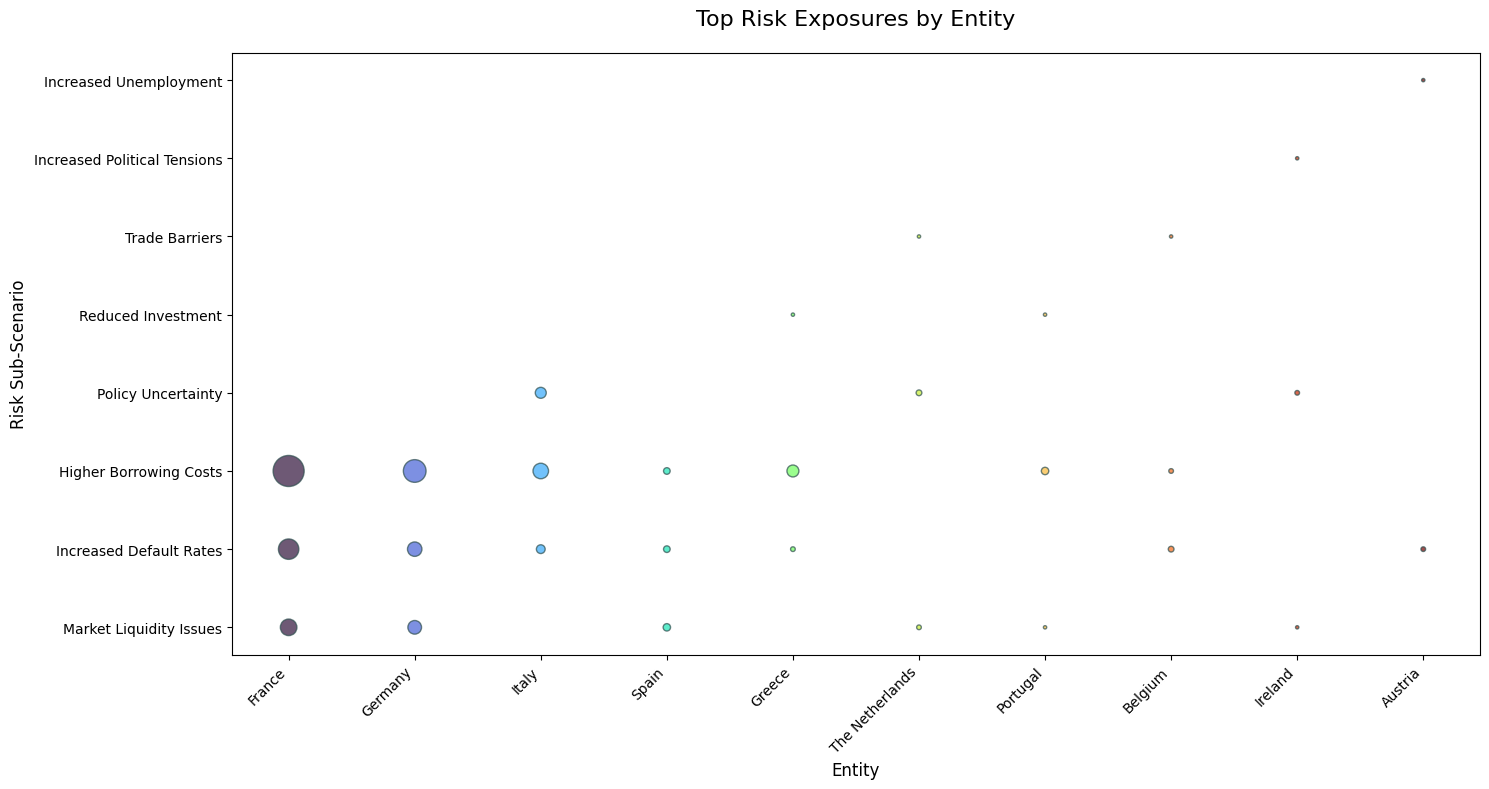

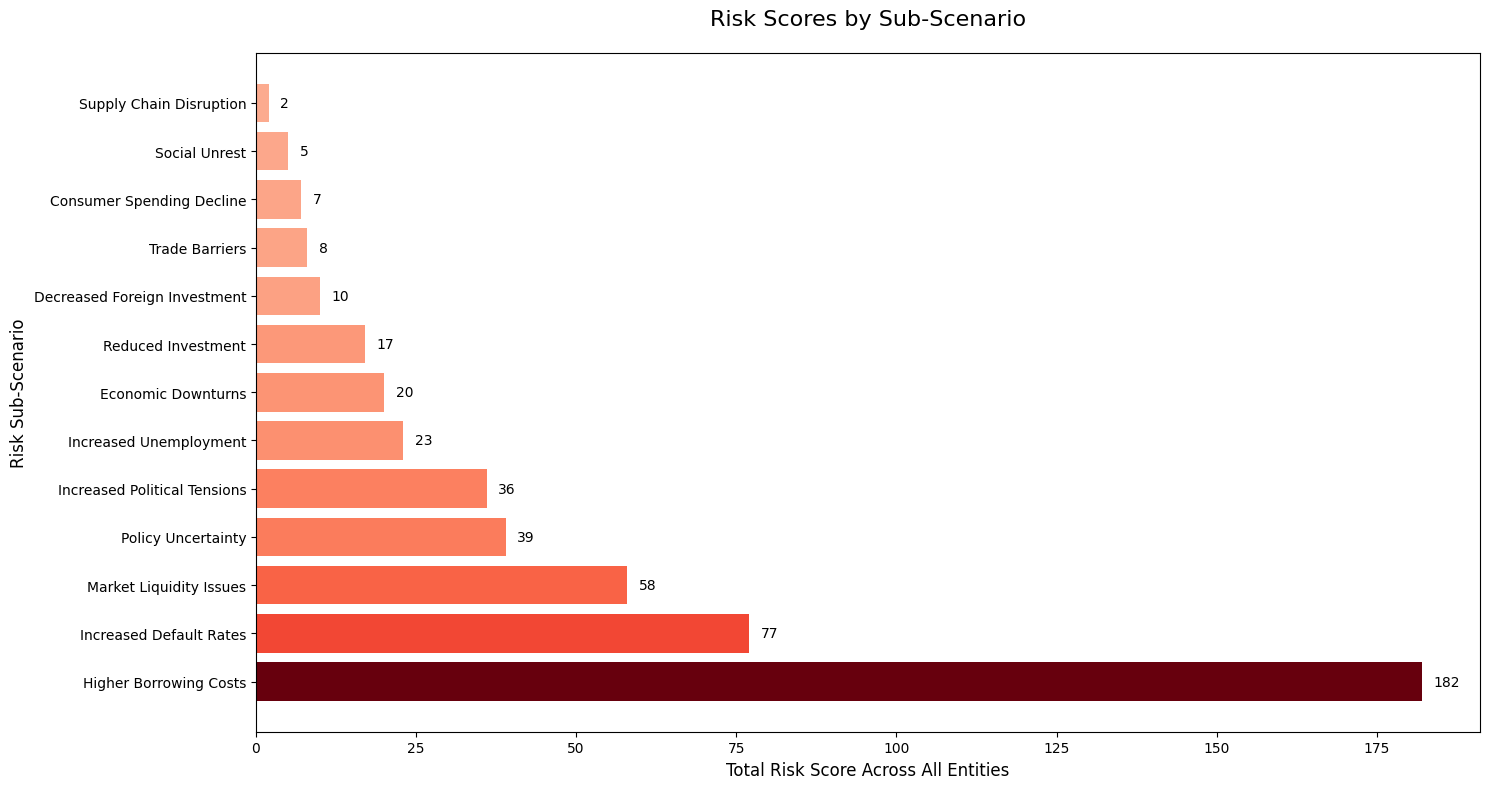

In [27]:
display_risk_figures_cookbooks(df_entity, interactive=False, n_entities=10)

## Export Results to CSV Files

Saves all generated datasets (labeled results, risk scores, daily indicators, country rankings) to CSV files in the output folder for further analysis or reporting.


In [ ]:
try:
    df_labels.to_csv(f"{output_dir}/labeled_search_results.csv", index=False)
    df_entity.to_csv(f"{output_dir}/entity_risk_scores.csv")
    daily_sentiment.to_csv(f"{output_dir}/daily_sentiment_indicators.csv")
    ranked_countries.to_csv(f"{output_dir}/peak_coverage_analysis.csv")
    df_combined.to_csv(f"{output_dir}/raw_search_results.csv", index=False)
except Exception as e:
    print(f"❌ Export error: {e}")